In [1]:
import numpy as np
from math import comb, lgamma, log, exp

def sample_a(n, d, m, seed=None, include_k_d=True):
    """
    Draw n samples of {a_k} with m hidden units, isotropic Gaussians for w1, w2, b1.
    Returns shape (n, d) if include_k_d=False (k=0..d-1), else (n, d+1) for k=0..d.
    """
    rng = np.random.default_rng(seed)

    # m-dimensional isotropic Gaussians for each sample
    w1 = rng.standard_normal((n, m))
    w2 = rng.standard_normal((n, m))
    b1 = rng.standard_normal((n, m))

    # k range
    K = np.arange(d + 1) if include_k_d else np.arange(d)  # (d+1,) or (d,)
    C = np.array([comb(d, int(k)) for k in K], dtype=np.float64)  # binomial coeffs

    # Broadcast powers: shapes -> (n, m, |K|)
    w1_pow = w1[:, :, None] ** K[None, None, :]
    b1_pow = b1[:, :, None] ** (d - K)[None, None, :]

    # Sum over m and scale
    A = (C[None, None, :] / np.sqrt(m)) * (w2[:, :, None] * w1_pow * b1_pow)
    A = A.sum(axis=1)  # shape (n, |K|)

    return A  # n-by-d (or n-by-(d+1) if include_k_d=True)

# Example
n, d, m = 1000, 4, 1000
A = sample_a(n, d, m, seed=0, include_k_d=True)

def normalize_rows(A, eps=1e-12):
    """
    Normalize each row of A to have L2 norm 1.
    Returns a new array of the same shape.
    """
    A = np.asarray(A, dtype=float)
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return A / np.maximum(norms, eps)

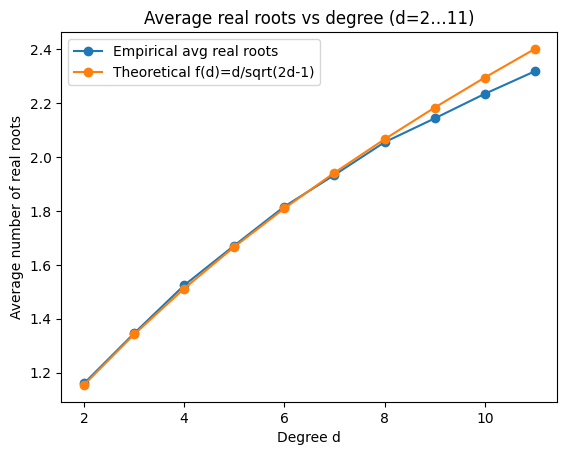

In [2]:
# Plot empirical average real roots vs degree and theoretical curve f(x) = x/sqrt(2x-1)
import numpy as np
import matplotlib.pyplot as plt

# Empirical data
d = np.array([2,3,4,5,6,7,8,9,10,11], dtype=float)
avg_real_roots = np.array([1.1600, 1.3458, 1.5240, 1.6714, 1.8160, 1.9332, 2.0544, 2.1428, 2.2338, 2.3176])

# Make the plot (single figure)
plt.figure()
plt.plot(d, avg_real_roots, marker='o', linestyle='-', label='Empirical avg real roots')
plt.plot(d, d/np.sqrt(2*d-1), marker='o', label='Theoretical f(d)=d/sqrt(2d-1)')
plt.xlabel('Degree d')
plt.ylabel('Average number of real roots')
plt.title('Average real roots vs degree (d=2…11)')
plt.legend()
plt.savefig("plot11.pdf")
plt.show()


In [3]:
from scipy.special import loggamma

def _odd_double_factorial_array(n):
    """
    n can be an array of integers that are odd or -1.
    Returns (n)!! with the convention (-1)!! = 1.
    Uses log-gamma for stability: (2m-1)!! = (2m)! / (2^m m!)
    where m = (n+1)/2.
    """
    n = np.asarray(n, dtype=np.int64)
    out = np.ones_like(n, dtype=float)

    mask = n >= 1  # odd positives
    m = (n[mask] + 1) // 2  # integer m
    # exp(lgamma(2m+1) - m*log(2) - lgamma(m+1))
    out[mask] = np.exp(loggamma(2*m + 1) - m * np.log(2.0) - loggamma(m + 1))

    # n == -1 already set to 1.0 by default
    return out

def covariance_matrix_a_inf(d: int) -> np.ndarray:
    """
    Build the (d+1) x (d+1) covariance matrix with entries:
      C[k1,k2] = binom(d,k1) binom(d,k2) (k1+k2-1)!! (2d-k1-k2-1)!!
      if k1+k2 is even; otherwise 0.
    """
    ks = np.arange(d + 1, dtype=np.int64)
    binom = np.array([comb(d, int(k)) for k in ks], dtype=float)  # (d+1,)

    K1, K2 = np.meshgrid(ks, ks, indexing="ij")
    S = K1 + K2  # pairwise sums

    # factors
    f1 = _odd_double_factorial_array(S - 1)           # (k1+k2-1)!!
    f2 = _odd_double_factorial_array(2 * d - S - 1)   # (2d-k1-k2-1)!!

    C = np.outer(binom, binom) * f1 * f2

    # zero out when k1+k2 is odd
    C[(S & 1) == 1] = 0.0
    return C

In [4]:
np.cov(A.T)

array([[105.24056283,  10.24532587,  96.48934501,   6.07453598,
         12.32736589],
       [ 10.24532587, 241.05349942,  21.00555911, 135.78890652,
         10.06965435],
       [ 96.48934501,  21.00555911, 329.00151668,  15.10737033,
         80.16286914],
       [  6.07453598, 135.78890652,  15.10737033, 224.73596664,
          1.76482524],
       [ 12.32736589,  10.06965435,  80.16286914,   1.76482524,
         95.78831554]])

In [5]:
covariance_matrix_a_inf(d = 4)

array([[105.,   0.,  90.,   0.,   9.],
       [  0., 240.,   0., 144.,   0.],
       [ 90.,   0., 324.,   0.,  90.],
       [  0., 144.,   0., 240.,   0.],
       [  9.,   0.,  90.,   0., 105.]])

In [6]:
# ---------- backends ----------
def count_real_roots_numpy(coeffs, tol=1e-8):
    """
    Count real roots via NumPy (falls back when phcpy not installed).
    coeffs are ascending by degree: a0, a1, ..., ad.
    """
    # np.roots expects highest degree first:
    c_desc = np.asarray(coeffs, dtype=float)[::-1]
    # Strip leading zeros (if any) to avoid a lower actual degree edge case:
    first_nz = np.argmax(np.abs(c_desc) > 0) if np.any(np.abs(c_desc) > 0) else 0
    c_desc = c_desc[first_nz:] if first_nz > 0 else c_desc
    if c_desc.size == 0:  # zero polynomial: define as 0 real roots
        return 0, np.array([])
    roots = np.roots(c_desc)
    real_mask = np.abs(roots.imag) <= tol
    return int(np.sum(real_mask)), roots[real_mask].real


# ---------- batch helpers ----------
def count_roots_for_matrix(A, tol=1e-8, **kwargs):
    """
    A: (n, d+1) or (n, d) matrix of coefficient rows (ascending powers).
    backend: "phcpy" or "numpy".
    Returns: counts (n,), and list of arrays of real roots per row.
    """
    counts = []
    roots_list = []
    for row in np.asarray(A):
        c, r = count_real_roots_numpy(row, tol=tol)
        counts.append(c)
        roots_list.append(r)
    return np.asarray(counts, dtype=int), roots_list


In [7]:
counts, roots = count_roots_for_matrix(A, tol=1e-8)

In [8]:
np.mean(counts)

np.float64(1.472)

In [9]:
d = np.arange(2, 12)
avg_counts = []
for deg in d:
    n, m = 400, 1600
    A = sample_a(n, deg, m, seed=2025)
    A = normalize_rows(A)
    counts, roots = count_roots_for_matrix(A, backend="numpy", tol=1e-7)
    avg_count = np.mean(counts)
    avg_counts.append(avg_count)
    print(f"d={deg}, avg real roots: {avg_count:.4f}")

avg_counts = np.array(avg_counts)


d=2, avg real roots: 1.1150
d=3, avg real roots: 1.3550
d=4, avg real roots: 1.4150
d=5, avg real roots: 1.6050
d=6, avg real roots: 1.7300
d=7, avg real roots: 1.8800
d=8, avg real roots: 1.9450
d=9, avg real roots: 2.0450
d=10, avg real roots: 2.1300
d=11, avg real roots: 2.1000


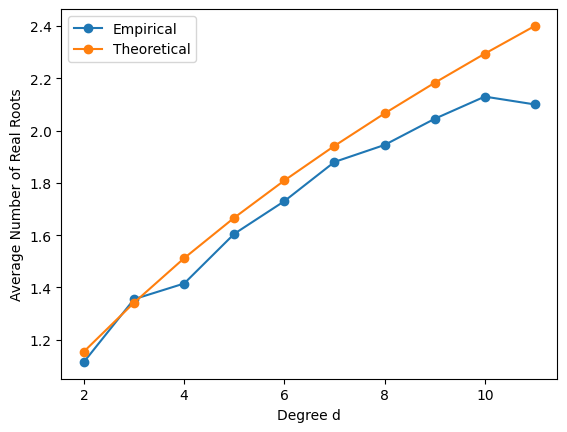

In [10]:
import matplotlib.pyplot as plt
plt.plot(d, avg_counts, marker='o')
plt.plot(d, d/np.sqrt(2*d-1), marker='o')
plt.xlabel("Degree d")
plt.ylabel("Average Number of Real Roots")
plt.legend(["Empirical", "Theoretical"])
plt.savefig("plot.pdf")
plt.show()